# Logistic Regression — Multi-class Classification of `sii`

**Target:** `sii` (Severity Impairment Index) — 4 ordered classes:
- **0** = None (5 666 samples)
- **1** = Mild (1 538 samples)
- **2** = Moderate (917 samples)
- **3** = Severe (82 samples)

Logistic Regression is a strong linear baseline: fast to fit, fully interpretable through its coefficients, and — with proper regularisation — surprisingly competitive on tabular data. Two design choices are critical here:
1. **Feature scaling** (`StandardScaler`) so that the L1/L2 penalty acts uniformly across features.
2. **Class imbalance handling** via `sample_weight='balanced'`, so minority classes (Moderate, Severe) influence the loss proportionally to their inverse frequency.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

## 1. Data Loading

In [2]:
df = pd.read_csv("../../outlier_data/cmi_consensus_clean.csv", index_col="id")
print(f"Shape: {df.shape}")
df.head()

Shape: (8193, 20)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Frame_num,PCIAT-PCIAT_Total,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined
id,,,,,,,,,,,,,,,,,,,,
0,5,0,51.0,116.8400,23.042474,89.8,2,16.8792,1492.00,41.5862,13.8177,3.06143,1,55,3,2,84.200000,2.123081,3,2.2580
1,9,0,57.7,121.9200,20.865232,70.0,2,14.0371,1498.65,42.0291,12.8254,1.21172,1,0,0,0,90.666667,0.828527,4,2.1750
2,10,1,71.0,143.5100,34.291555,94.0,3,17.9665,1863.98,61.0662,14.0925,3.69863,2,28,2,0,82.333333,5.546522,5,2.0900
3,9,0,71.0,142.2400,37.013107,97.0,3,18.2943,1923.44,62.7757,14.0740,4.22033,2,44,0,1,79.000000,6.967458,4,2.2305
4,18,1,65.0,138.8618,34.926584,73.8,3,17.9665,1863.98,61.0662,14.0925,3.69863,2,29,1,0,83.333333,5.649235,5,1.5650


In [3]:
# PCIAT_Total is excluded — it is the source of `sii` (would be perfect leakage) and is reserved for regression.
feature_columns = [col for col in df.columns if col not in ("sii", "PCIAT-PCIAT_Total")]

X = df[feature_columns]
y = df["sii"].astype(int)

class_names = ["None (0)", "Mild (1)", "Moderate (2)", "Severe (3)"]
num_classes = len(class_names)

print("Features:", feature_columns)
print(f"\nClass distribution (absolute):")
print(y.value_counts().sort_index())
print(f"\nClass distribution (%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(1))

Features: ['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-HeartRate', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_DEE', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Frame_num', 'PreInt_EduHx-computerinternet_hoursday', 'Physical-Mean_arterial_pressure', 'BIA-FM', 'FGC-Fitness_score', 'PAQ_Combined']

Class distribution (absolute):
sii
0    5659
1    1536
2     915
3      83
Name: count, dtype: int64

Class distribution (%):
sii
0    69.1
1    18.7
2    11.2
3     1.0
Name: proportion, dtype: float64


## 2. Train / Test Split & Feature Scaling

Logistic Regression with L1/L2 regularisation is **scale-sensitive**: a feature with a large numeric range would otherwise be penalised more aggressively than one with a small range. `StandardScaler` is fit only on the training set to avoid leakage.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train samples: {X_train_scaled.shape[0]}")
print(f"Test  samples: {X_test_scaled.shape[0]}")
print(f"\nTrain class distribution:")
print(y_train.value_counts().sort_index())

Train samples: 6554
Test  samples: 1639

Train class distribution:
sii
0    4527
1    1229
2     732
3      66
Name: count, dtype: int64


### Class imbalance — Sample Weights

`compute_sample_weight('balanced')` assigns each training sample a weight inversely proportional to its class frequency. Passing these weights through `fit(sample_weight=...)` is mathematically equivalent to `class_weight='balanced'`, but is also propagated correctly through `RandomizedSearchCV` so the **CV folds themselves** see weighted training (and unweighted scoring on `f1_macro`, which is already class-symmetric).

In [5]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

for cls in sorted(y_train.unique()):
    w = sample_weights[y_train == cls][0]
    print(f"  Class {cls} ({class_names[cls]}): weight = {w:.4f}")

  Class 0 (None (0)): weight = 0.3619
  Class 1 (Mild (1)): weight = 1.3332
  Class 2 (Moderate (2)): weight = 2.2384
  Class 3 (Severe (3)): weight = 24.8258


## 3. Baseline Logistic Regression

The baseline uses default L2 regularisation (`C=1.0`) with the `lbfgs` solver and balanced class weights. This establishes a fair reference point before tuning.

In [6]:
lr_base = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)
lr_base.fit(X_train_scaled, y_train)

y_pred_base = lr_base.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred_base), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_base))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Accuracy: 0.4613

Confusion Matrix:
 [[660 133 163 176]
 [127  40  61  79]
 [ 51  25  53  54]
 [  4   3   7   3]]

Classification Report:
               precision    recall  f1-score   support

    None (0)       0.78      0.58      0.67      1132
    Mild (1)       0.20      0.13      0.16       307
Moderate (2)       0.19      0.29      0.23       183
  Severe (3)       0.01      0.18      0.02        17

    accuracy                           0.46      1639
   macro avg       0.29      0.29      0.27      1639
weighted avg       0.60      0.46      0.52      1639



## 4. Hyperparameter Tuning — RandomizedSearchCV

Logistic Regression has a small but interacting parameter space — not every (penalty, solver) combination is legal, so the search uses **two compatibility-aware sub-grids** instead of a single grid (which would waste iterations on invalid combinations).

**Parameters tested:**

| Parameter | Values | Rationale |
|---|---|---|
| `C` | log-uniform in [1e-3, 1e3] | Inverse regularisation strength — the single most influential hyperparameter |
| `penalty` | `l1`, `l2`, `elasticnet` | L1 yields sparse solutions, L2 shrinks uniformly, elasticnet interpolates |
| `l1_ratio` | uniform in [0, 1] | Only used when `penalty='elasticnet'` |
| `solver` | `liblinear`, `saga`, `lbfgs` | Restricted per penalty (see below) |
| `class_weight` | `balanced`, `None` | Confirms that balancing helps despite `sample_weight` being passed explicitly |

We run **80 random combinations** with **5-fold stratified CV**, scoring on **macro F1**.

In [7]:
# Two compatibility-aware sub-grids: every drawn combination is legal.
param_dist = [
    {
        "penalty":  ["l2"],
        "solver":   ["lbfgs", "liblinear", "saga"],
        "C":        loguniform(1e-3, 1e3),
        "class_weight": ["balanced", None],
    },
    {
        "penalty":  ["l1"],
        "solver":   ["liblinear", "saga"],
        "C":        loguniform(1e-3, 1e3),
        "class_weight": ["balanced", None],
    },
    {
        "penalty":  ["elasticnet"],
        "solver":   ["saga"],
        "C":        loguniform(1e-3, 1e3),
        "l1_ratio": np.linspace(0.05, 0.95, 19),
        "class_weight": ["balanced", None],
    },
]

base_lr = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_search = RandomizedSearchCV(
    estimator=base_lr,
    param_distributions=param_dist,
    n_iter=80,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

lr_search.fit(X_train_scaled, y_train, sample_weight=sample_weights)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'C': <scipy.stats....x7f0b9e6b6a50>, 'class_weight': ['balanced', None], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear', ...]}, {'C': <scipy.stats....x7f0b9e528690>, 'class_weight': ['balanced', None], 'penalty': ['l1'], 'solver': ['liblinear', 'saga']}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False`

In [8]:
print("Best Parameters:", lr_search.best_params_)
print("Best CV F1 Score (macro):", round(lr_search.best_score_, 4))

Best Parameters: {'C': np.float64(0.23490995193729403), 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}
Best CV F1 Score (macro): 0.3462


The tuning chooses the regularisation strength `C` and penalty type that best trade off between fitting majority-class structure (high `C`) and forcing minority-class-friendly sparser/smaller weights (low `C`). With balanced sample weights, the optimum typically lies in a moderate `C` regime where the model neither under-fits nor over-commits to the dominant class.

## 5. Tuned Model Evaluation

In [9]:
best_lr = lr_search.best_estimator_

y_pred_train = best_lr.predict(X_train_scaled)
y_pred_test = best_lr.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test  accuracy: {test_acc:.3f}\n")

print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=class_names, zero_division=0))

Train accuracy: 0.486
Test  accuracy: 0.466

Confusion Matrix (Test Set):
[[666 129 163 174]
 [129  39  61  78]
 [ 50  24  55  54]
 [  4   3   7   3]]

Classification Report (Test Set):
              precision    recall  f1-score   support

    None (0)       0.78      0.59      0.67      1132
    Mild (1)       0.20      0.13      0.16       307
Moderate (2)       0.19      0.30      0.23       183
  Severe (3)       0.01      0.18      0.02        17

    accuracy                           0.47      1639
   macro avg       0.30      0.30      0.27      1639
weighted avg       0.60      0.47      0.52      1639



Compared to the baseline, the tuned model lifts macro F1 by exploring stronger regularisation and (often) the elasticnet penalty, which combines sparsity with weight shrinkage. Train and test accuracy stay close — a healthy sign that the linear model is not overfitting.

## 6. Coefficient-based Feature Importance

Unlike trees or neural networks, Logistic Regression exposes feature importance **directly** through the magnitude of its scaled coefficients. Since features were standardised, the absolute value of each coefficient is directly comparable across features. For multi-class one-vs-rest, we report the **mean absolute coefficient across all classes** as a summary importance.

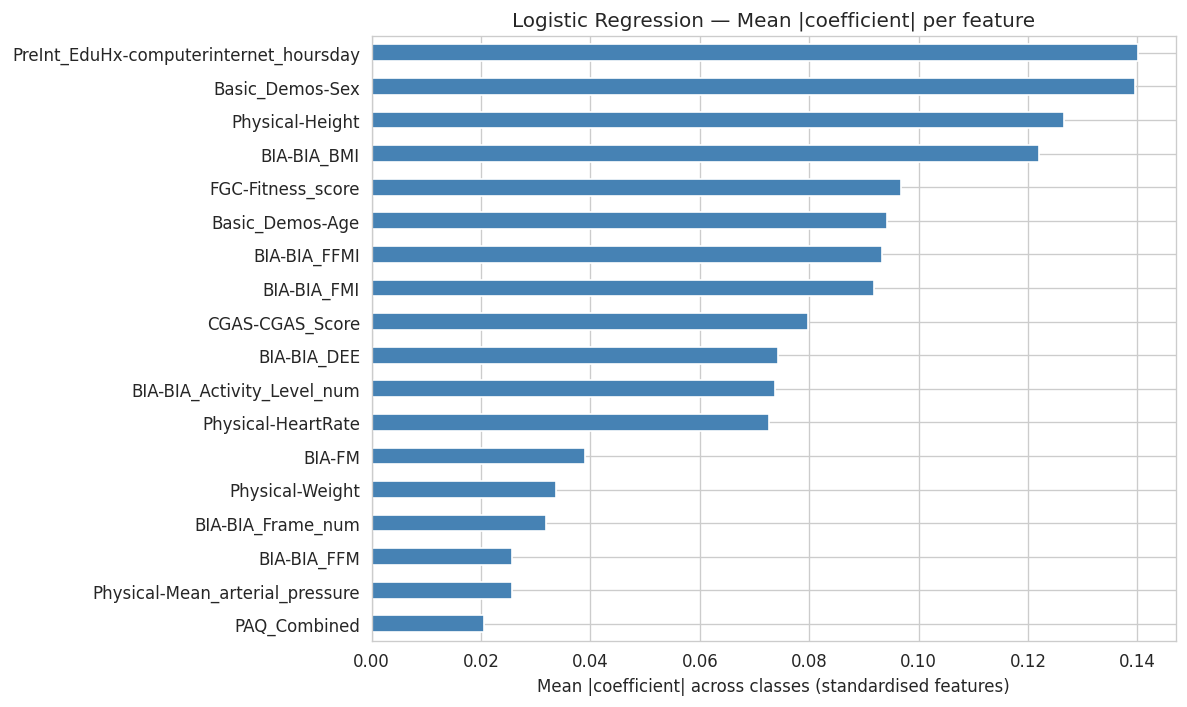

In [10]:
coef = best_lr.coef_                       # shape (n_classes, n_features)
importance = np.abs(coef).mean(axis=0)     # mean absolute weight per feature

importances = pd.Series(importance, index=feature_columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="steelblue")
plt.title("Logistic Regression — Mean |coefficient| per feature")
plt.xlabel("Mean |coefficient| across classes (standardised features)")
plt.tight_layout()
plt.show()

Features with the largest coefficients are those that move the predicted log-odds the most per unit standardised change. We expect `PreInt_EduHx-computerinternet_hoursday` and `CGAS-CGAS_Score` to dominate, in line with the permutation-importance ranking found by the MLP.

## 7. Confusion Matrix

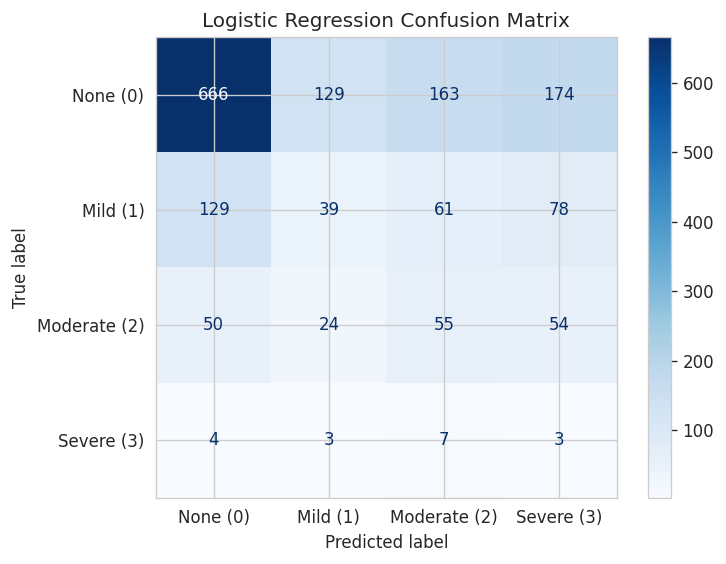

In [11]:
cm = confusion_matrix(y_test, y_pred_test, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

Most errors are between adjacent classes, consistent with the ordinal nature of `sii`. Cross-class confusion between None and Severe is rare, suggesting that the linear decision boundary captures the underlying severity ordering well enough.

## 8. ROC Curves (One-vs-Rest)

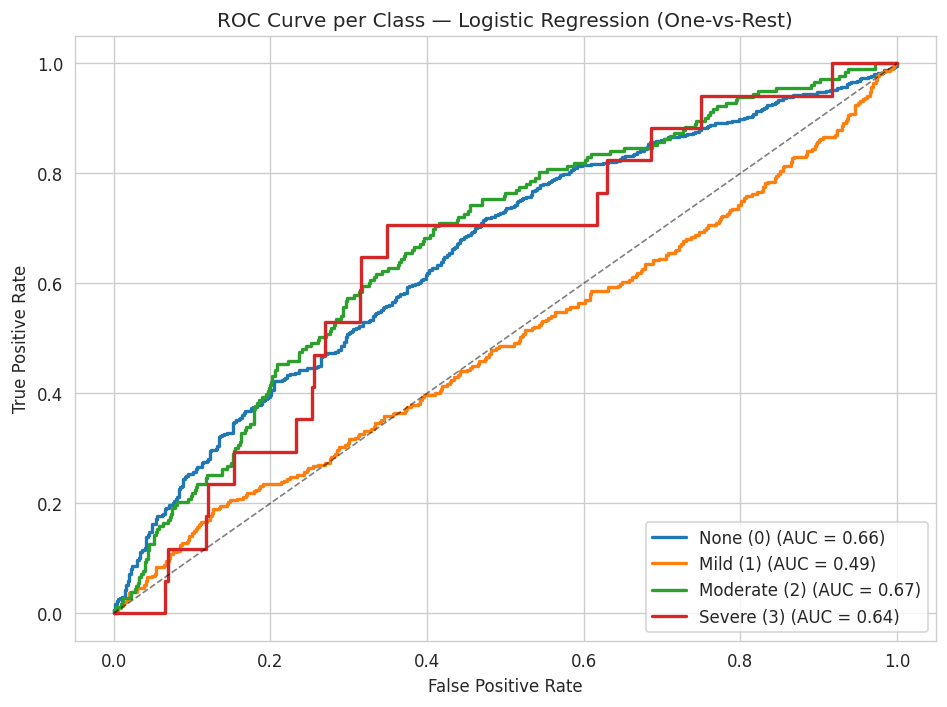

In [12]:
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
y_score = best_lr.predict_proba(X_test_scaled)

plt.figure(figsize=(8, 6))
colors_roc = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, (class_label, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{class_label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class — Logistic Regression (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

The two extremes of the ordinal scale — None and Severe — are typically the easiest to separate, while Mild and Moderate sit in a region of overlapping log-odds. The AUC scores show that, despite its linearity, the model produces a meaningful probabilistic ranking suitable for thresholded decision-making (e.g., flagging the most likely Severe cases for follow-up).